# Challenge - MNIST Clasificación
`Sergio Andres Amortegui Ardila`


# Introduction

This notebook presents a guided solution for the challenge, there are functions outside the notebook in different files for different motives:

1. Production grade separation of concerns.
2. Modularity.
3. Scabibility.
4. Readability.

We focus on the forth side for this notebook given we want to structure the narrative of solution as clean and professional as possible. 
Setting heavy machinery and implementations inside their own file to not overload the notebook.
Nevertheless, it is imperative to notice that, even though the heavy content of the implementation is not presented explicitly on the notebook, it does not mean it is not specified and detailed on each section, here a complete in depth description and analysis of each section is presented.

The main notebook (this one) is presented in english for standardization purposes. However, there is an spanish version available at (route......).

## Autoreload Changes

In [1]:
%load_ext autoreload
%autoreload 2

# Required Imports

In [ ]:
# Modules
import os
import sys
import torch
import numpy as np
from pathlib import Path
import PIL
from PIL import Image

# Add the project root to the path so we can import from src
sys.path.append(os.path.abspath(".."))

# Mnist Dataloaders
from src.data.mnist import load_mnist_dataloaders

# Data Preprocessing & Transforms
from src.utils.preprocessing import preprocess_handwritten_image
from src.data.augmentation import test_transforms

# Custom Neural Network
from src.models.mnist_cnn import MNISTCNN

# Training Loop
from src.training.engine import train, test_model
from src.utils.lib.schema import TrainHistory

# Evaluation Metrics
# TODO: Create metrics.

# Plots
from src.utils.plot import (
    plot_train_history,
    plot_confusion_matrix,
    print_classification_report,
    plot_predictions,
)

# Utils
from src.utils.device import get_device

# MNIST Dataset

What was the objective to do data augmentation?

The idea behind it was to perfect the pattern recognition of the numbers as well to provide a model capable of performing better outside the controlled experiment environment.
Meaning we could (in hypothesis) provide correct predictions agains our oun written numbers on a given paper or digital figure.

In [3]:
# Load MNIST data loaders
train_loader, eval_loader, test_loader, metadata = load_mnist_dataloaders()

## Minimal EDA

In [4]:
# TODO: Implement EDA.

# Model Implementation

## Neural Network

A neural network architecture was selected so solve this problem becuase .....


```bash
MNISTCNN(
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (dropout2d): Dropout2d(p=0.25, inplace=False)
  (relu): ReLU()
)
```

In [5]:
# TODO: Create mermaid diagram.

In [6]:
# Instatiation of the model
model = MNISTCNN()

## Optimizer

For this task the best optimizer is ....

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Loss Function (Criterion)
The criterion selected is .....

In [8]:
criterion = torch.nn.CrossEntropyLoss()

# Training

## Device Identification

Here we seek for the optimal device to use in the training. 

For a windows, it would be optimal to train with CUDA available gpus.
For mac, it would be optimal to train with metal available ....
Otherwise, use the default cpu method, which would be slower but will get the job done.


This will be used inside the training loop to assign the device for the model and both the training and evaluation data.

In [9]:
# Identify device
device = get_device()


## Hyperparameters

...

In [10]:
epochs = 22

## Training Loop

In [11]:
run_training = True
if run_training:
    model, history = train(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        train_dataloader=train_loader,
        eval_dataloader=eval_loader,
        epochs=epochs,
        device=device,
    )

Epochs:   5%|▍         | 1/22 [00:10<03:38, 10.39s/epoch]

Epoch 1/22 | train_loss=0.5674 | train_acc=0.8146 | eval_loss=0.1029 | eval_acc=0.9690


Epochs:   9%|▉         | 2/22 [00:20<03:25, 10.26s/epoch]

Epoch 2/22 | train_loss=0.2698 | train_acc=0.9191 | eval_loss=0.0733 | eval_acc=0.9778


Epochs:  14%|█▎        | 3/22 [00:30<03:11, 10.08s/epoch]

...

Epoch 20/22 | train_loss=0.1167 | train_acc=0.9654 | eval_loss=0.0330 | eval_acc=0.9907


Epochs:  95%|█████████▌| 21/22 [03:28<00:09,  9.86s/epoch]

Epoch 21/22 | train_loss=0.1047 | train_acc=0.9679 | eval_loss=0.0317 | eval_acc=0.9908


Epochs: 100%|██████████| 22/22 [03:38<00:00,  9.94s/epoch]

Epoch 22/22 | train_loss=0.1086 | train_acc=0.9684 | eval_loss=0.0360 | eval_acc=0.9897


In [12]:
artifacts_dir = "artifacts"

### Save History

In [13]:
if run_training:
    path = Path(f"{artifacts_dir}/history.json")
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(history.model_dump_json(indent=4), encoding="utf-8")

### Read History

In [14]:
path = Path(f"{artifacts_dir}/history.json")
history = TrainHistory.model_validate_json(path.read_text(encoding="utf-8"))

# Model Persistency

In [ ]:
# Output Folder
output_dir = "../artifacts/mnist_classifier"

## Save Model

In [16]:
# Make sure the data directory exists
os.makedirs(output_dir, exist_ok=True)
# Save model
torch.save(model.state_dict(), f"{output_dir}.pt")


## Read Model

In [17]:
# Build MNIST Model
model = MNISTCNN()
model.load_state_dict(torch.load(f"{output_dir}.pt", map_location=device))
model.to(device)
model.eval()

MNISTCNN(
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (dropout2d): Dropout2d(p=0.5, inplace=False)
  (relu): ReLU()
)

# Metrics and Evaluation

## Testing

In [ ]:
labels, predictions, images = test_model(
    model=model, test_dataloader=test_loader, device=device
)

## Training History

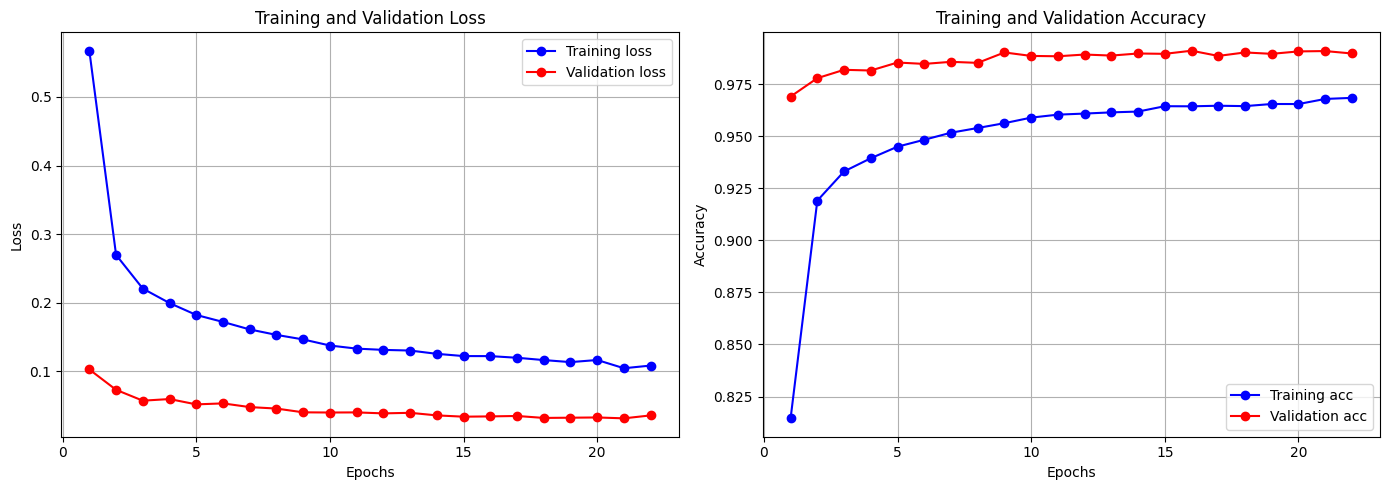

In [19]:
plot_train_history(history)

## Confusion Matrix

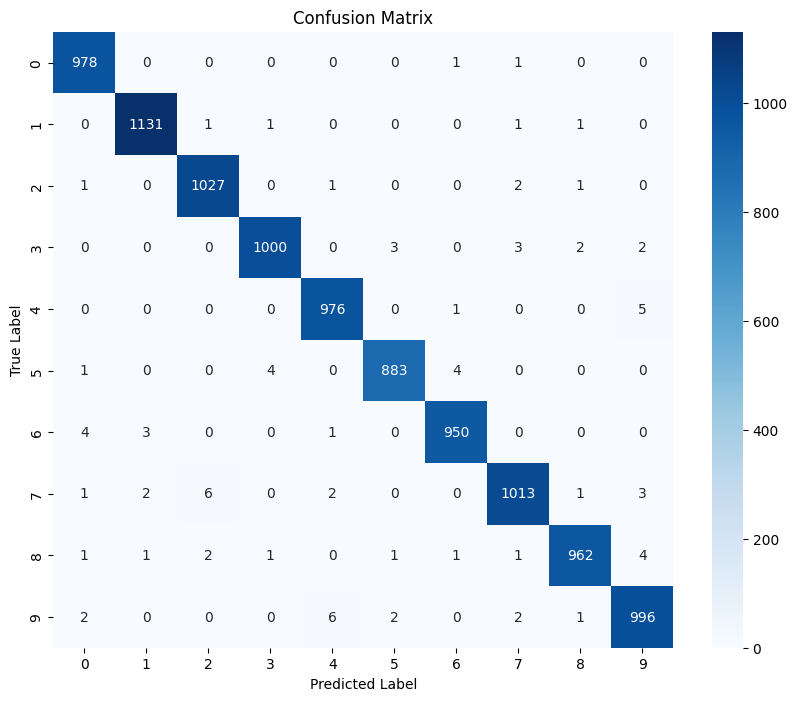

In [20]:
plot_confusion_matrix(labels, predictions, list(sorted(set(labels))))

## Classification Report

In [21]:
print_classification_report(labels, predictions, list(sorted(set(labels))))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Visualization of Predictions

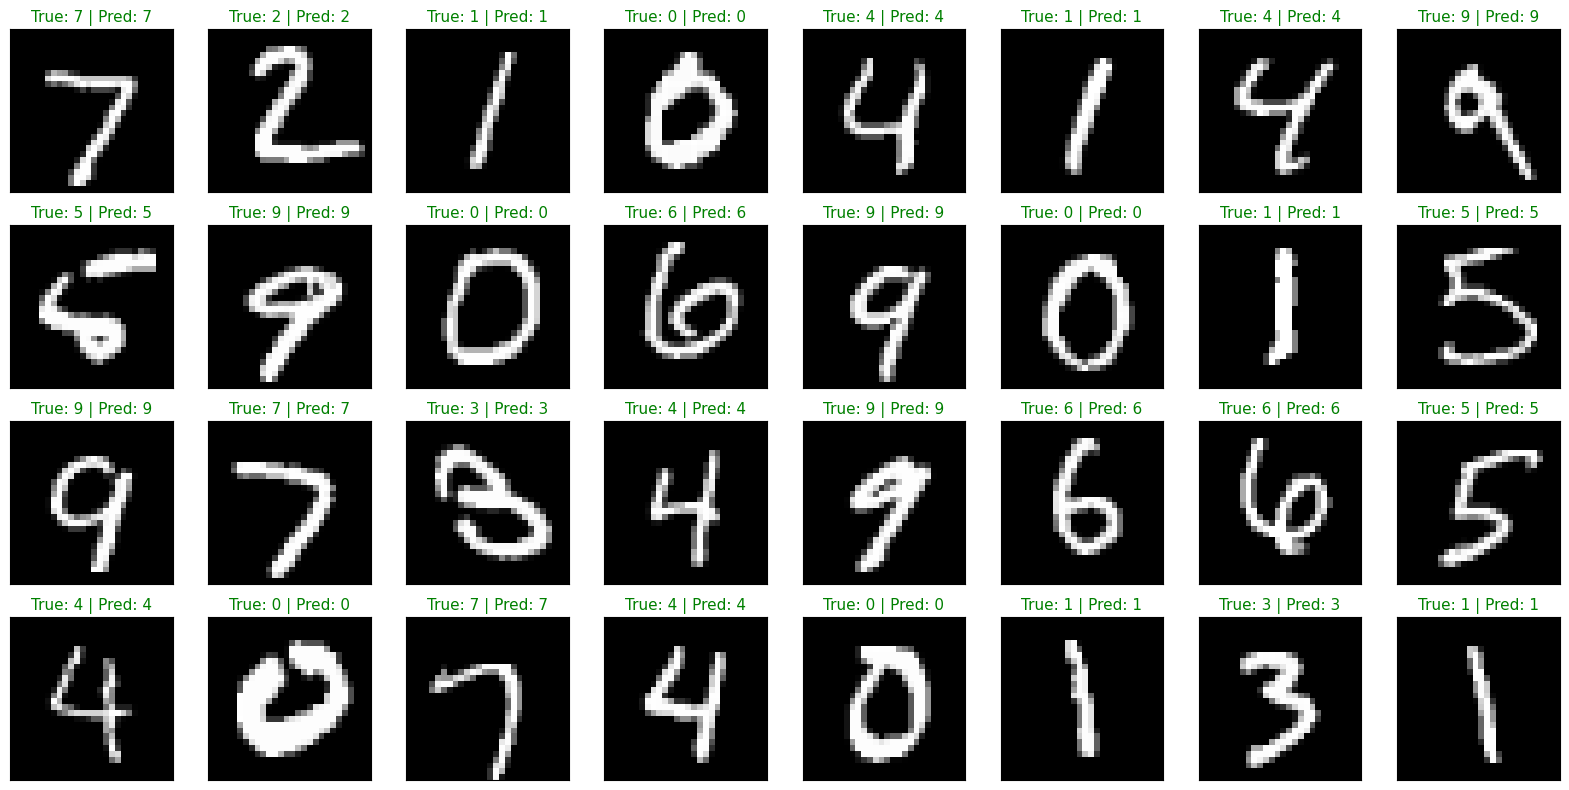

In [22]:
plot_predictions(images, labels, predictions, 32)

## Own Predictions

In [32]:
folder_path = Path("../images")

image_paths = sorted(
    list(folder_path.glob("*.png"))
    + list(folder_path.glob("*.jpg"))
    + list(folder_path.glob("*.JPG"))
    + list(folder_path.glob("*.jpeg"))
)

images = []
filenames = []

for image_path in image_paths:
    tensor = preprocess_handwritten_image(image_path)
    images.append(tensor)
    filenames.append(image_path.name)

images_tensor = torch.stack(images)
labels = [int(s[0]) for s in filenames]
print(labels)

[1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 4, 5, 7, 9]


[1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 4, 5, 7, 9]
[1 2 1 1 2 1 3 3 3 3 3 4 5 7 9]


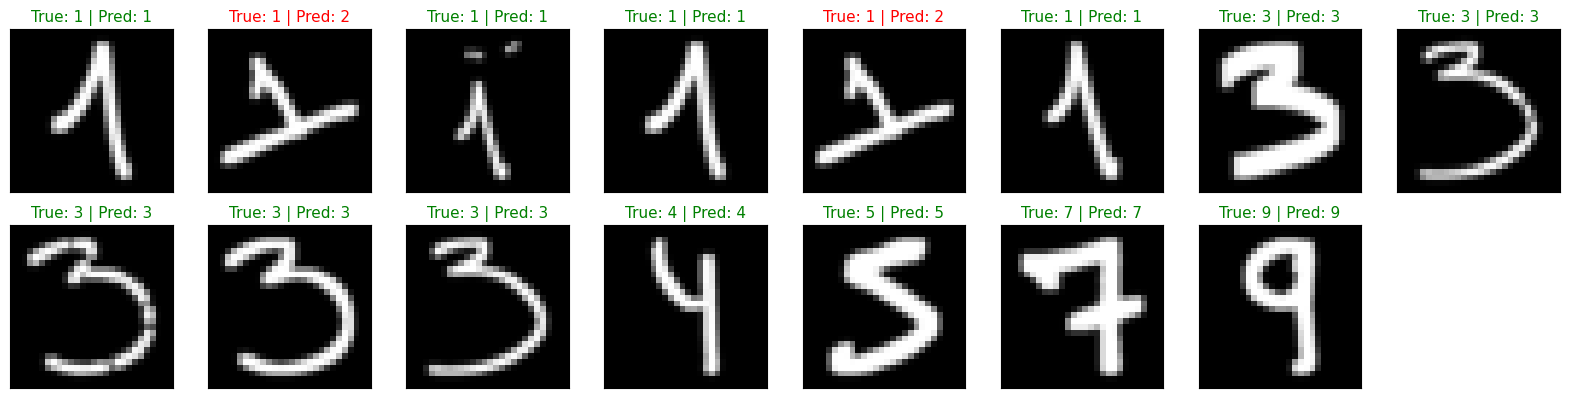

In [33]:
model.to(device)
model.eval()

with torch.inference_mode():
    images_device = images_tensor.to(device)
    output = model(images_device)
    predictions = output.argmax(dim=1)

predsss = predictions.cpu().numpy()

print(labels)
print(predsss)

plot_predictions(images_tensor, labels, predictions.cpu().numpy(), 15)